In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
a_stock = pd.read_csv('stock_spot_china_a.csv')[['证券代码','一级行业','二级行业','三级行业']]

In [67]:
tuple(a_stock[a_stock['一级行业'].isin(['金融'])]['二级行业'].unique())

('房地产', '非银金融', '贵金属', '银行')

In [17]:
def prepare_raw(source):
    df = pd.read_excel(source + '.xlsx') 
    df = df.dropna(subset = ['证券名称']).replace('——',np.nan).dropna(how = 'all').dropna(axis = 1, how = 'all').fillna(0)
    df.columns = [x.replace('\n[报告类型]合并报表\n[单位]元','').replace('\n[报告期]','').replace(source,'') for x in df.columns.tolist()]
    df.columns = [x.replace('年一季','0331').replace('年二季/中报','0630').replace('年三季','0930').replace('年年报','1231') for x in df.columns.tolist()]
    df = a_stock.merge(df, on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
    return df

capex = prepare_raw('资本支出')
inventory = prepare_raw('存货')
income = prepare_raw('营业收入')

In [50]:
start_date = '2004-01-01'
industry_level = '二级行业'
industry_name = '汽车整车'

def calculate_change(df):
    df = df[df[industry_level].isin([industry_name])].groupby([industry_level]).sum().T/100000000
    df.index = pd.to_datetime(df.index)
    df = df[(df.index > start_date)].sum(axis=1)
    df = ((df - df.shift(4)) / df.shift(4)).dropna(how='all')
    return df

capex_df = calculate_change(capex)
inventory_df = calculate_change(inventory)
income_df = calculate_change(income)
df = pd.concat([capex_df, inventory_df, income_df], axis=1).rename(columns={0: "资本支出", 1: "存货", 2:"营业收入"}).round(2)

In [69]:
import plotly.express as px


historical_percentile = (inventory_df.tail(1)[0] - inventory_df.min()) / (inventory_df.max() - inventory_df.min())

fig = px.line(df, color_discrete_sequence = ['red','yellow','lightgreen'], title = industry_name+'行业库存周期 - 历史分位值:'+ "{:.0%}".format(historical_percentile) ,
              labels={
                     "value": "同比增长率",
                     "index": "",
                     "variable": ""
                 },)
def fig_render(fig):
    fig.update_layout({
        'plot_bgcolor': 'rgba(0, 0, 0, 0)',
        'paper_bgcolor': 'rgba(0, 0, 0, 0)',
        'margin': dict(autoexpand=True,l=0,r=0,b=0),
        'showlegend': True
        })
    fig.update_coloraxes(showscale=False)
    fig.update_yaxes(zeroline = True, zerolinecolor = 'white', zerolinewidth = 0.5)
    return fig

fig =  fig_render(fig)
fig

0.2530926554987692

<AxesSubplot:xlabel='一级行业,二级行业'>

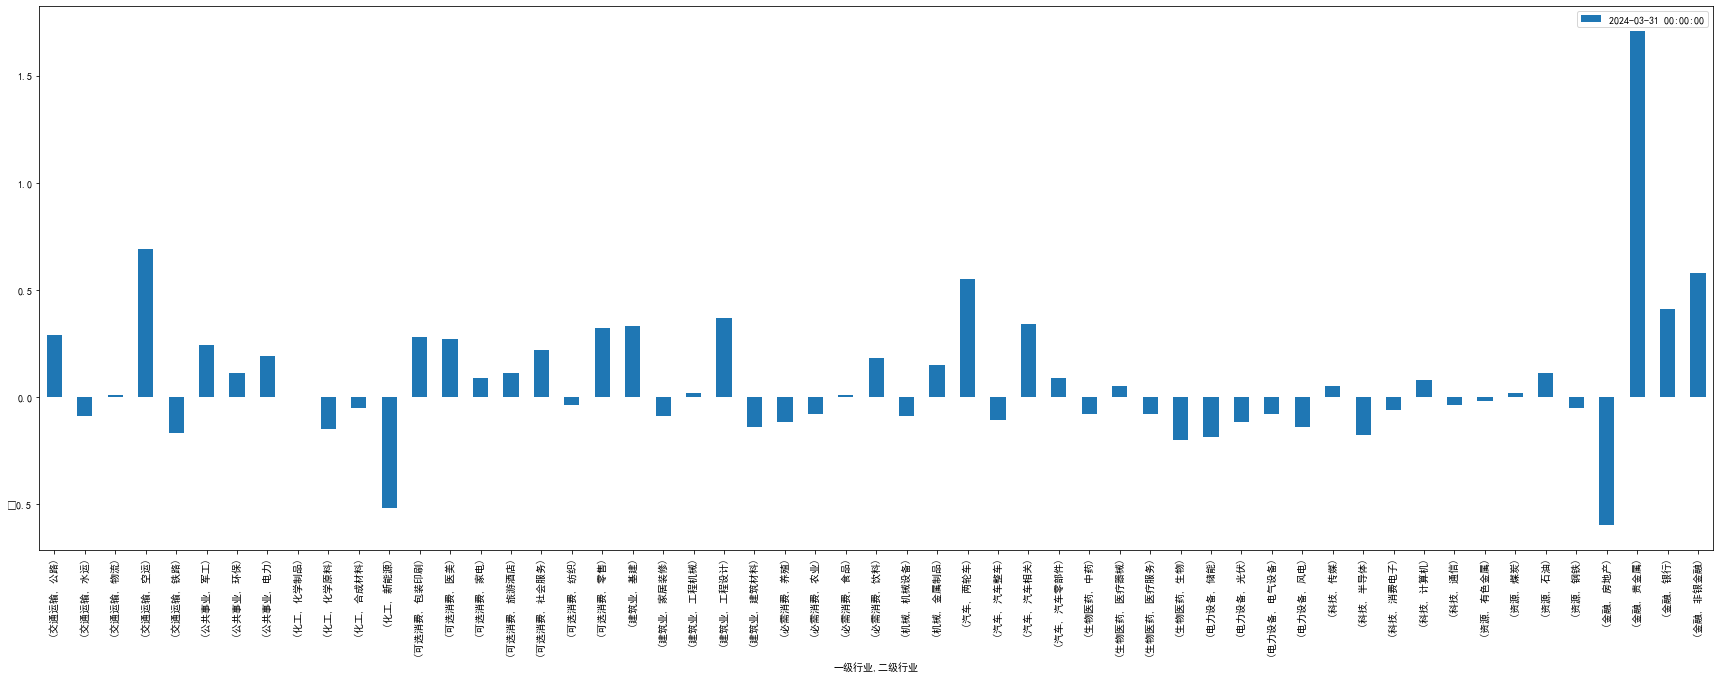

In [522]:
df = capex.groupby(['一级行业','二级行业']).sum().T/100000000
df.index = pd.to_datetime(df.index)
df = ((df - df.shift(4)) / df.shift(4)).dropna(how='all').round(2)
df.tail(1).T.plot.bar(figsize=(30,10))

In [33]:
help(pd.qcut)

Help on function qcut in module pandas.core.reshape.tile:

qcut(x, q, labels=None, retbins: 'bool' = False, precision: 'int' = 3, duplicates: 'str' = 'raise')
    Quantile-based discretization function.
    
    Discretize variable into equal-sized buckets based on rank or based
    on sample quantiles. For example 1000 values for 10 quantiles would
    produce a Categorical object indicating quantile membership for each data point.
    
    Parameters
    ----------
    x : 1d ndarray or Series
    q : int or list-like of float
        Number of quantiles. 10 for deciles, 4 for quartiles, etc. Alternately
        array of quantiles, e.g. [0, .25, .5, .75, 1.] for quartiles.
    labels : array or False, default None
        Used as labels for the resulting bins. Must be of the same length as
        the resulting bins. If False, return only integer indicators of the
        bins. If True, raises an error.
    retbins : bool, optional
        Whether to return the (bins, labels) or not.

C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/276073472.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = total_inventory[total_inventory['二级行业'].isin(industry) ].groupby(['二级行业','三级行业']).sum().T/100000000


<AxesSubplot:>

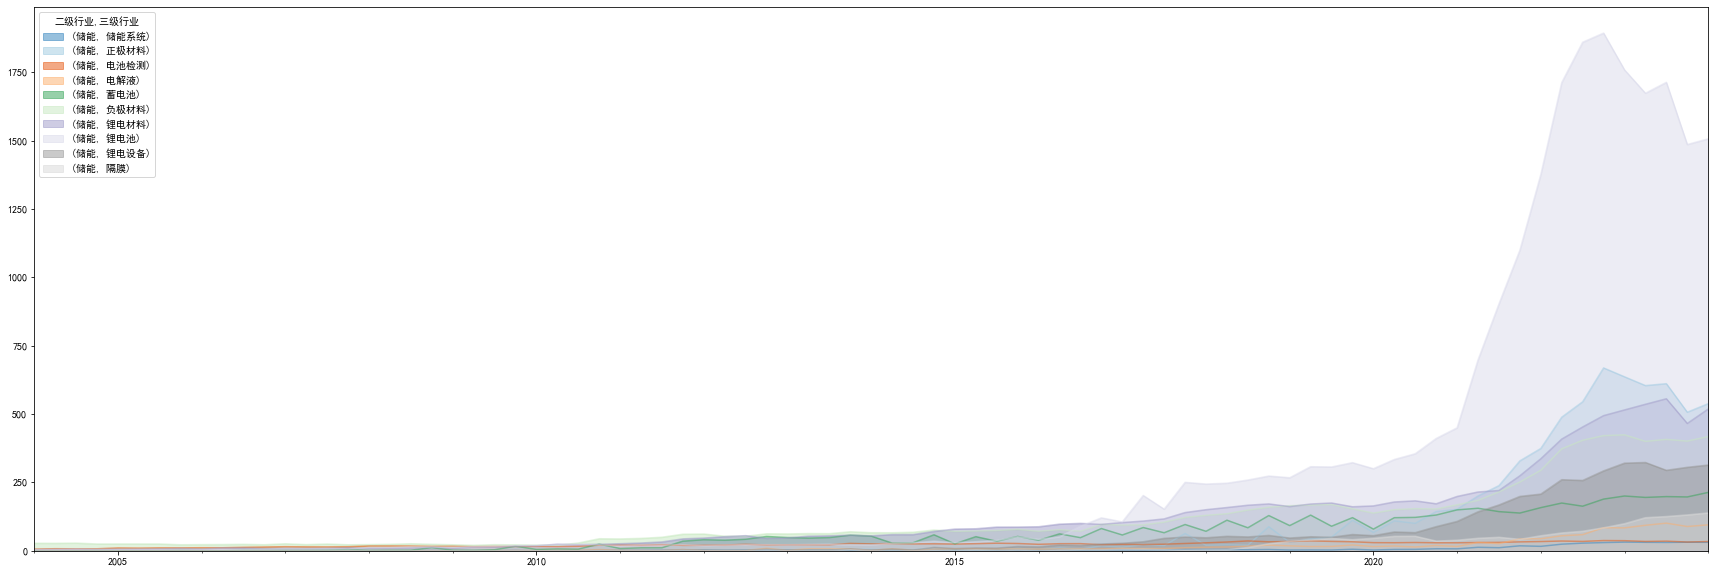

In [359]:
industry = ['储能']
# df = total_inventory[total_inventory['一级行业'].isin([industry])].groupby(['一级行业','二级行业']).sum().T   & (total_inventory['二级行业'] == '基建')
df = total_inventory[total_inventory['二级行业'].isin(industry) ].groupby(['二级行业','三级行业']).sum().T/100000000

df.index = pd.to_datetime(df.index)
df = df[(df.index > '2004-01-01')]
df.plot.area(stacked=False,xlabel = '',figsize=(30,10), colormap = 'tab20c')



C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/1000706001.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inventory_df = inventory[inventory['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/1000706001.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  in_built_df  = in_built[in_built['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T


<AxesSubplot:>

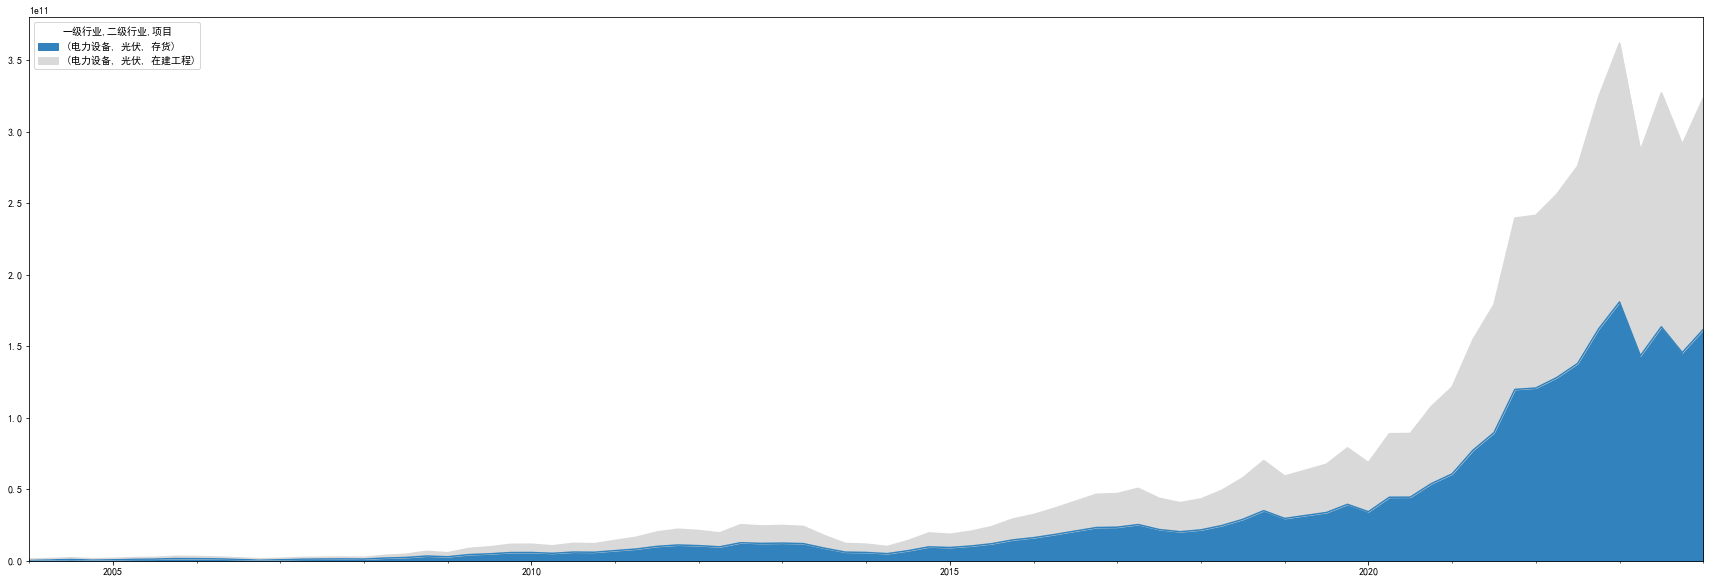

In [318]:
inventory = in_built.round(2)
inventory = a_stock.merge(inventory.reset_index(), on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
in_built = in_built.round(2)
in_built = a_stock.merge(in_built.reset_index(), on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
inventory['项目'] = '存货'
in_built['项目'] = '在建工程'

industry = '光伏'
inventory_df = inventory[inventory['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
in_built_df  = in_built[in_built['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
df = inventory_df.merge(in_built_df, left_on=inventory_df.index, right_on=in_built_df.index).set_index(keys=['key_0'])
df.index = pd.to_datetime(df.index)
df = df[(df.index > '2004-01-01')]
df.plot.area(stacked=True,xlabel = '',figsize=(30,10), colormap = 'tab20c')

In [126]:
import requests

url = 'https://datacenter-web.eastmoney.com/api/data/v1/get'
params = {
    'sortColumns': 'NOTICE_DATE,SECURITY_CODE',
    'sortTypes': '-1,-1',
    'pageSize': '6000',
    'pageNumber': '1',
    'reportName': 'RPT_DMSK_FN_BALANCE',
    'columns': 'ALL',
    'filter': '(SECURITY_TYPE_CODE in ("058001001","058001008"))(TRADE_MARKET_CODE!="069001017")' + "(REPORT_DATE='2020-03-31')" + "(EndDate='2024-04-30')"
}

r = requests.get(url, params=params, timeout=10)
data_json = r.json()

In [127]:
data_json

{'version': None,
 'result': None,
 'success': False,
 'message': 'EndDate列不存在',
 'code': 9501}

In [120]:
pd.set_option('display.max_columns', None)

pd.DataFrame(data_json['result']['data']).dropna(axis=1, how='all')

TypeError: 'NoneType' object is not subscriptable

In [128]:
from mootdx.affair import Affair

# 远程文件列表
files = Affair.files()



In [129]:
files

[{'filename': 'gpcw20240930.zip',
  'hash': '697aa0f931ea8bc16989a7caa0b4f492',
  'filesize': 165},
 {'filename': 'gpcw20240630.zip',
  'hash': '229ca99789110834b777da49482d6b0e',
  'filesize': 165},
 {'filename': 'gpcw20240331.zip',
  'hash': '0dee1d192f7dd492635e909b9303c1b5',
  'filesize': 4776683},
 {'filename': 'gpcw20231231.zip',
  'hash': '88d1e39b2fdba9cd9d3e25d77dfc0b71',
  'filesize': 5448875},
 {'filename': 'gpcw20230930.zip',
  'hash': '42f5eaabdf4ce7a9e438b6e37355992f',
  'filesize': 5072491},
 {'filename': 'gpcw20230630.zip',
  'hash': '9987df39d61c3461f54e7def2735b245',
  'filesize': 5388105},
 {'filename': 'gpcw20230331.zip',
  'hash': '9cbfd6ccb2d134ee13568d6b524d5313',
  'filesize': 4714437},
 {'filename': 'gpcw20221231.zip',
  'hash': 'c984f2395fe2eb968c1e9459fbdf83c4',
  'filesize': 5416650},
 {'filename': 'gpcw20220930.zip',
  'hash': '94dd6fc16bb295d4a0fdda1144251300',
  'filesize': 4779792},
 {'filename': 'gpcw20220630.zip',
  'hash': 'ae11cb837b13199d30384ea1ad3

In [134]:
# 下载单个
Affair.fetch(downdir='tmp', filename='gpcw20240331.zip')
result = Affair.parse(downdir='tmp', filename='gpcw20240331.zip')

4.78MB [00:11, 404kB/s] 


In [139]:
columns = [
    'report_date',
    '基本每股收益',
    '扣除非经常性损益每股收益',
    '每股未分配利润',
    '每股净资产',
    '每股资本公积金',
    '净资产收益率',
    '每股经营现金流量',

    '存货',
    '在建工程',
 
    '商誉',
 
    '资产总计',
    '负债合计',

    '流动比率(非金融类指标)',
    '速动比率(非金融类指标)',
    '现金比率(%)(非金融类指标)',

    '权益乘数(%)',

    '存货周转率(非金融类指标)',

    '存货周转天数(非金融类指标)',
 
    '营业收入增长率(%)',
    '净利润增长率(%)',
    '扣非净利润同比(%)',
  
    '营业利润率(非金融类指标)',
 
    '净资产收益率',
    
    '销售净利率(%)',
    '总资产报酬率',
    '净利润率(非金融类指标)',
    '销售毛利率(%)(非金融类指标)',
 
    
  
    '存货比率(非金融类指标)',
   
    
    '总股本',
  
    
    '第一大股东的持股数量',
    '十大流通股东持股数量合计(股)',
    '十大股东持股数量合计(股)',
    
    
    '机构总量（家）',
    '机构持股总量(股)',
    'QFII机构数',
    'QFII持股量',
    '券商机构数',
    '券商持股量',
    '保险机构数',
    '保险持股量',
    '基金机构数',
    '基金持股量',
    '社保机构数',
    '社保持股量',
    '私募机构数',
    '私募持股量',
    '财务公司机构数',
    '财务公司持股量',
    '年金机构数',
    '年金持股量',
    '十大流通股东中持有A股合计(股)',
    '第一大流通股东持股量(股)',
    '自由流通股(股)',
    '受限流通A股(股)',
    '一般风险准备(金融类)',
    '其他综合收益(利润表)',
    '综合收益总额(利润表)',
    '归属于母公司股东权益(资产负债表)',
    '银行机构数(家)(机构持股)',
    '银行持股量(股)(机构持股)',
    '一般法人机构数(家)(机构持股)',
    '一般法人持股量(股)(机构持股)',
    '近一年净利润(元)',
    '信托机构数(家)(机构持股)',
    '信托持股量(股)(机构持股)',
    '特殊法人机构数(家)(机构持股)',
    '特殊法人持股量(股)(机构持股)',
    
    '加权净资产收益率(每股指标)',

    '国家队持股数量（万股)',

    '基本每股收益（单季度）',

]
 


In [141]:
result[columns]

,report_date,基本每股收益,扣除非经常性损益每股收益,每股未分配利润,每股净资产,每股资本公积金,净资产收益率,净资产收益率,每股经营现金流量,存货,在建工程,商誉,资产总计,负债合计,流动比率(非金融类指标),速动比率(非金融类指标),现金比率(%)(非金融类指标),权益乘数(%),存货周转率(非金融类指标),存货周转天数(非金融类指标),营业收入增长率(%),净利润增长率(%),扣非净利润同比(%),营业利润率(非金融类指标),净资产收益率,净资产收益率,销售净利率(%),总资产报酬率,净利润率(非金融类指标),销售毛利率(%)(非金融类指标),存货比率(非金融类指标),总股本,第一大股东的持股数量,十大流通股东持股数量合计(股),十大股东持股数量合计(股),机构总量（家）,机构持股总量(股),QFII机构数,QFII持股量,券商机构数,券商持股量,保险机构数,保险持股量,基金机构数,基金持股量,社保机构数,社保持股量,私募机构数,私募持股量,财务公司机构数,财务公司持股量,年金机构数,年金持股量,十大流通股东中持有A股合计(股),第一大流通股东持股量(股),自由流通股(股),受限流通A股(股),一般风险准备(金融类),其他综合收益(利润表),综合收益总额(利润表),归属于母公司股东权益(资产负债表),银行机构数(家)(机构持股),银行持股量(股)(机构持股),一般法人机构数(家)(机构持股),一般法人持股量(股)(机构持股),近一年净利润(元),信托机构数(家)(机构持股),信托持股量(股)(机构持股),特殊法人机构数(家)(机构持股),特殊法人持股量(股)(机构持股),加权净资产收益率(每股指标),国家队持股数量（万股),基本每股收益（单季度）
code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
000001,20240331,0.6600,0.660000,12.0595,21.420000,4.1617,3.075,3.075,-1.100,0.000000e+00,0.000000e+00,7.568000e+09,5.729398e+12,5.243822e+12,0.000,0.000,0.000000,11.80,0.000,0.0,-14.030000,2.260000,3.020000,47.860001,3.075,3.075,38.509998,0.264,38.514000,0.000000,0.000000,1.940592e+10,9.618541e+09,1.270886e+10,1.270886e+10,108.0,1.293820e+10,0.0,0.0,0.0,0.0,4.0,1.130401e+10,101.0,464342144.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.270886e+10,9.618541e+09,8.160428e+09,371248.0,6.804800e+10,3.450000e+08,1.527700e+10,4.855760e+11,0.0,0.0,1.0,6.252337e+07,4.678500e+10,0.0,0.0,1.0,429232704.0,3.15,42923.269531,0.6600
000002,20240331,-0.0305,-0.140362,7.8163,21.007401,2.1231,-0.144,-0.144,-0.790,6.720567e+11,2.526615e+09,5.537868e+09,1.463869e+12,1.064336e+12,1.385,0.547,10.353000,3.66,0.080,1125.0,-10.050000,-125.040001,-359.380005,1.100000,-0.144,-0.144,0.540000,-0.024,-0.588000,10.820000,60.487000,1.193071e+10,3.242811e+09,6.888030e+09,6.888030e+09,50.0,4.772160e+09,0.0,0.0,0.0,0.0,0.0,0.000000e+00,43.0,294185504.0,0.0,0.0,1.0,137271120.0,0.0,0.0,0.0,0.0,4.681680e+09,3.242811e+09,6.474125e+09,7260668.0,0.000000e+00,-5.092358e+07,2.803668e+08,2.506333e+11,0.0,0.0,3.0,3.803746e+09,1.795313e+10,0.0,0.0,2.0,318147584.0,-0.14,31814.759766,-0.0305
000006,20240331,-0.0197,-0.019920,2.1726,5.144900,0.3588,-0.383,-0.383,-0.236,1.712965e+10,7.426350e+06,0.000000e+00,2.576530e+10,1.835193e+10,1.753,0.364,28.177999,3.48,0.010,8591.0,-4.870000,-120.070000,-100.680000,-10.720000,-0.383,-0.383,-11.400000,-0.103,-10.525000,29.180000,79.250000,1.349995e+09,2.960314e+08,5.677226e+08,5.677226e+08,5.0,5.275306e+08,0.0,0.0,0.0,0.0,0.0,0.000000e+00,1.0,6398700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.677226e+08,2.960314e+08,8.505992e+08,7650.0,0.000000e+00,0.000000e+00,-2.880840e+07,6.945543e+09,0.0,0.0,2.0,4.993882e+08,-9.174792e+08,0.0,0.0,1.0,16052200.0,-0.38,1605.219971,-0.0197
000007,20240331,0.0018,0.001674,-0.9219,0.364800,0.4532,0.507,0.507,0.077,3.573825e+07,0.000000e+00,0.000000e+00,3.969639e+08,2.585759e+08,2.185,1.906,147.231003,2.87,1.021,88.0,-12.610000,375.970001,-71.709999,2.070000,0.507,0.507,0.840000,0.161,1.480000,22.830000,12.756000,3.464480e+08,4.500013e+07,1.073046e+08,1.423395e+08,2.0,7.887339e+07,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.073046e+08,4.500013e+07,2.300747e+08,37500000.0,0.000000e+00,0.000000e+00,3.648482e+05,1.264008e+08,0.0,0.0,2.0,7.887339e+07,3.749978e+07,0.0,0.0,0.0,0.0,0.51,0.000000,0.0018
000008,20240331,-0.0179,-0.020025,-0.7036,1.290700,0.9644,-1.387,-1.387,-0.050,8.559517e+08,8.227626e+08,2.383081e+09,1.066344e+10,7.059682e+09,0.750,0.618,8.077000,2.96,0.126,712.0,-58.200001,-47.560001,-59.459999,-27.700001,-1.387,-1.387,-29.750000,-0.456,-26.962000,42.020000,17.556999,2.716378e+09,7.124184e+08,1.240216e+09,1.270441e+09,4.0,1.124621e+09,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.240216e+09,7.124184e+08,1.613531e+09,40428424.0,0.000000e+00,1.378204e+05,-5.350668e+07,3.506032e+09,0.0,0.0,3.0,1.086172e+09,-8.473612e+08,0.0,0.0,0.0,0.0,-1.54,0.000000,-0.0179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...